IMPORTATION DE LA BIBIOTHEQUE openCV

In [19]:
import matplotlib.pyplot as plt

In [20]:
import cv2 as cv

CHARGERMENT DE L'IMAGE

In [21]:
image = cv.imread('flyers.jpg')


AFFICHAGE DE L'IMAGE

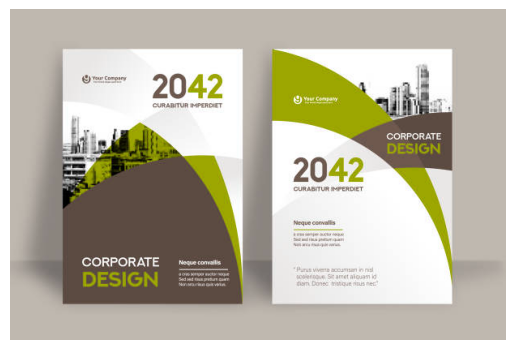

In [22]:
plt.imshow(image)#Image BGR telle que traitée par opencv
plt.axis('off')
plt.show()

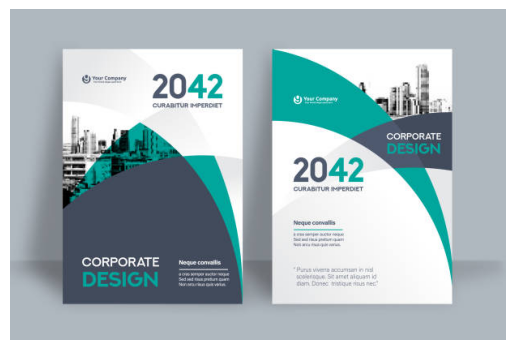

In [23]:
image_1 = cv.cvtColor(image, cv.COLOR_BGR2RGB)#Conversion de l'image en RGB car opencv traite les image avec le BGR donc pour avoir l'image en couleur rgb on doit convertir cette image en RGB
plt.imshow(image_1)
plt.axis('off')
plt.show()

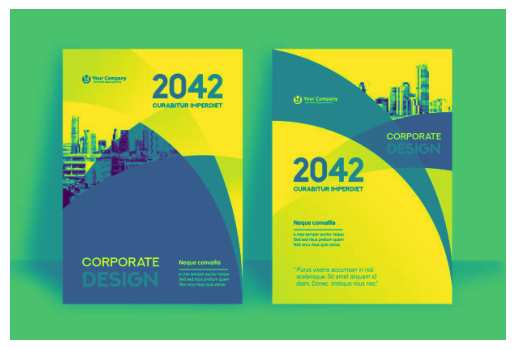

In [24]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2GRAY)#Conversion de l'image en niveau de gris
plt.imshow(image_2)
plt.axis('off')
plt.show()

In [25]:
"""
Ecrivons deux fonctions pour afficher les images en niveau de gris et rgb
"""

def afficherRGB(titre, image):
    image =  cv.cvtColor(image, cv.COLOR_BGR2RGB)#Conversion de l'image en niveau de gris
    plt.imshow(image)
    plt.axis('off')
    plt.title(titre)
    plt.show()
    return image


def afficherGRAY(titre, image):
    image =  cv.cvtColor(image, cv.COLOR_BGR2GRAY)#Conversion de l'image en niveau de gris
    plt.imshow(image)
    plt.title(titre)
    plt.axis('off')
    plt.show()
    return image

def afficherImage(titre, image):
    plt.imshow(image)
    plt.title(titre)
    plt.axis('off')
    plt.show()

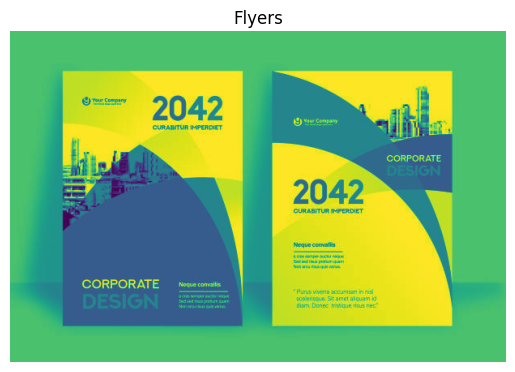

In [26]:
gray_image = afficherGRAY("Flyers", image)

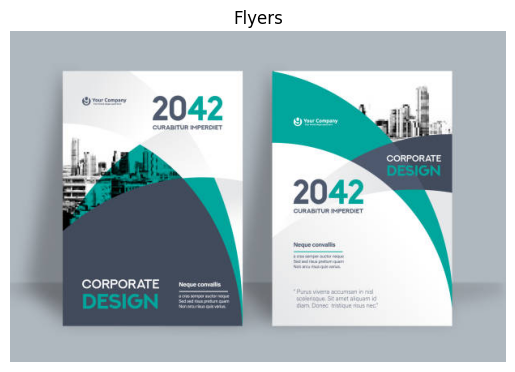

In [27]:
rgb_image = afficherRGB('Flyers', image)

REDIMENSIONEMENT DE L'IMAGE

In [28]:
"""  Affichage des dimensions de l'image en niveau de gris et rgb"""

print(f'Dimension image en niveau de gris : {gray_image.shape}')
print("Dimension image en rgb : {}".format(rgb_image.shape))

Dimension image en niveau de gris : (408, 612)
Dimension image en rgb : (408, 612, 3)


In [29]:
print(f"Hauteur de l'image rgb {rgb_image.shape[0]}")
print(f"Largeur de l'image rgb {rgb_image.shape[1]}")
print(f"Profondeur de l'image rgb {rgb_image.shape[2]}")

Hauteur de l'image rgb 408
Largeur de l'image rgb 612
Profondeur de l'image rgb 3


In [30]:
print(f"Hauteur de l'image en niveau de gris {gray_image.shape[0]}")
print(f"Largeur de l'image en niveau de gris {gray_image.shape[1]}")

Hauteur de l'image en niveau de gris 408
Largeur de l'image en niveau de gris 612


SÉPARTION D'IAMGES

In [31]:
"""Nous allons séparer une image RGB en trois image B, G  et R, Gcorrespondant a la representation de l'image dans chaque espace de couleur"""

image_B, image_G, image_R = cv.split(image)

# Affichage des dimensions
print(f"Dimension de l'image_R : {image_R.shape}")
print(f"Dimension de l'image_G : {image_G.shape}")
print(f"Dimension de l'image_B : {image_B.shape}")


Dimension de l'image_R : (408, 612)
Dimension de l'image_G : (408, 612)
Dimension de l'image_B : (408, 612)


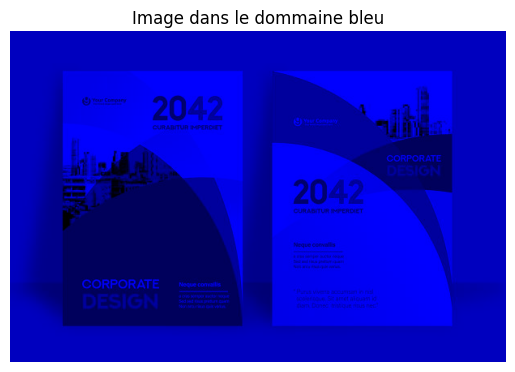

"On crée la matrice zeros pour donner la valeur zero a tous les autres poixels \nlorsque que l'on se trouve dans un domaine de couleur precis(Bleu, vert ou rouge) afin d'avoir une image avec des valeurs de \npixels que dans cet espace la car le reste sera a zero "

In [32]:
import numpy as np
zeros = np.zeros(image.shape[:2], dtype="uint8")

afficherImage("Image dans le dommaine bleu", cv.merge([zeros, zeros, image_B])) #Matplotlib attend le format RGB et opencv renvoie l'image au format BGR donc on doit premuter l'ordre pour garder la cohérence dans l'affichage

"""On crée la matrice zeros pour donner la valeur zero a tous les autres poixels 
lorsque que l'on se trouve dans un domaine de couleur precis(Bleu, vert ou rouge) afin d'avoir une image avec des valeurs de 
pixels que dans cet espace la car le reste sera a zero """

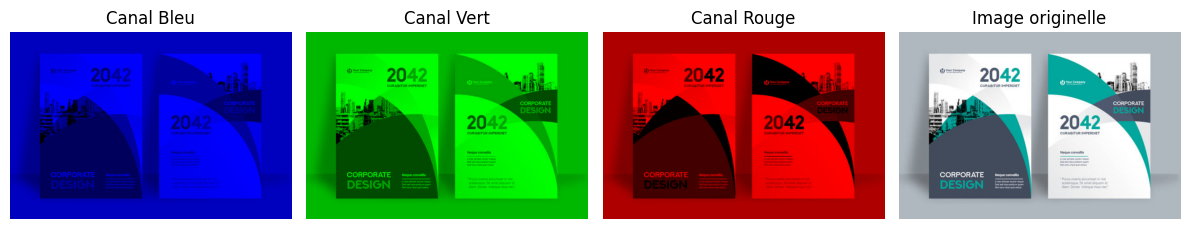

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12, 5))
axs[0].imshow(cv.merge([zeros, zeros, image_B]))
axs[0].set_title('Canal Bleu')
axs[0].axis('off')
axs[1].imshow(cv.merge([zeros, image_G, zeros]))
axs[1].set_title('Canal Vert')
axs[1].axis('off')
axs[2].imshow(cv.merge([image_R, zeros, zeros]))
axs[2].set_title('Canal Rouge')
axs[2].axis('off')
merge_image = cv.merge([image_B, image_G, image_R]) #OpenCV utilise l’ordre des canaux BGR (Bleu, Vert, Rouge)
merge_image_rgb = cv.cvtColor(merge_image, cv.COLOR_BGR2RGB)
axs[3].imshow(merge_image_rgb)
axs[3].set_title('Image originelle')
axs[3].axis('off')
plt.tight_layout()
plt.show()

TRANSLATION D'UNE IMAGE

hauteur originale : 408
 nouvelle_hauteur : 51.0
 largeur originale : 612
 nouvelle largeur : 76.5


(-0.5, 611.5, 407.5, -0.5)

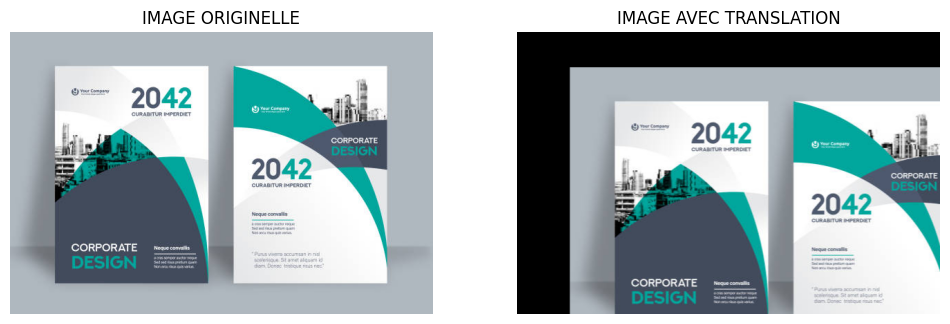

In [51]:
hauteur, largeur = image.shape[:2]

nouvelle_hauteur, nouvelle_largeur = hauteur/8, largeur/8

print(f"hauteur originale : {hauteur}\n nouvelle_hauteur : {nouvelle_hauteur}\n largeur originale : {largeur}\n nouvelle largeur : {nouvelle_largeur}")

T = np.float32([[1, 0,  nouvelle_largeur], [0, 1, nouvelle_hauteur]]) #Matrice de translation

image_translate = cv.warpAffine(image, T, (largeur, hauteur))



fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
axs[0].set_title('IMAGE ORIGINELLE')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(image_translate, cv.COLOR_BGR2RGB))
axs[1].set_title('IMAGE AVEC TRANSLATION')
axs[1].axis('off')

ROTATION D'IMAGE

(-0.5, 611.5, 407.5, -0.5)

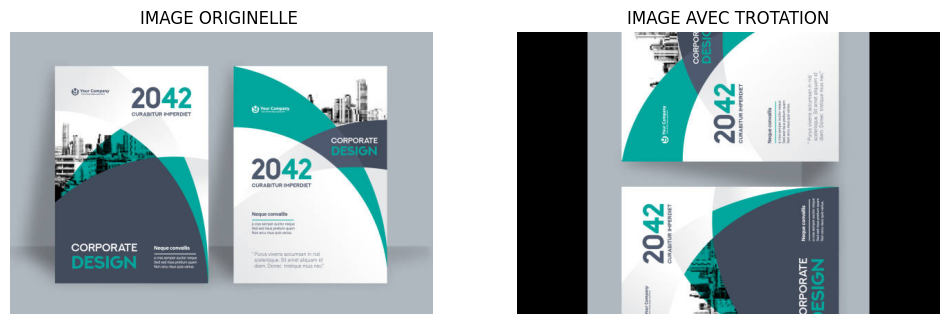

In [54]:
matrice_rotation = cv.getRotationMatrix2D((largeur/2, hauteur/2), angle=90, scale=1)
"""
On divise la taille de l'image par deux pour roter l'image par rapport au centre 
"""

image_rotee = cv.warpAffine(image, matrice_rotation, (largeur, hauteur))



fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
axs[0].set_title('IMAGE ORIGINELLE ')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(image_rotee, cv.COLOR_BGR2RGB))
axs[1].set_title('IMAGE AVEC TROTATION')
axs[1].axis('off')

TRANSPOSEE D'UNE IMAGE

(-0.5, 407.5, 611.5, -0.5)

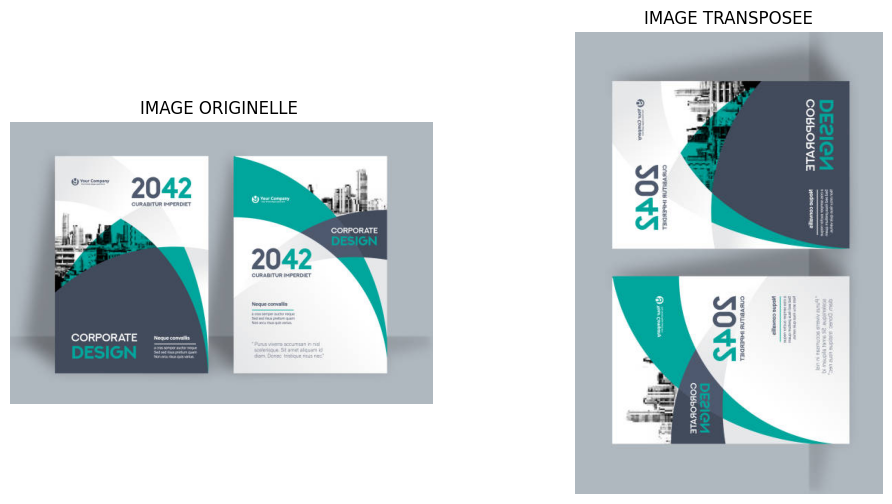

In [55]:
image_transposee = cv.transpose(image)



fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
axs[0].set_title('IMAGE ORIGINELLE ')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(image_transposee, cv.COLOR_BGR2RGB))
axs[1].set_title('IMAGE TRANSPOSEE')
axs[1].axis('off')

FLIP D'IMAGE

(-0.5, 611.5, 407.5, -0.5)

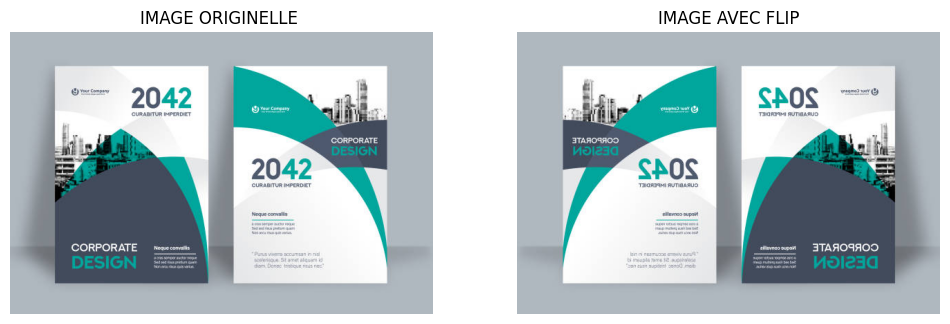

In [59]:
image_flipee = cv.flip(image, 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
axs[0].set_title('IMAGE ORIGINELLE ')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(image_flipee, cv.COLOR_BGR2RGB))
axs[1].set_title('IMAGE AVEC FLIP')
axs[1].axis('off')

SAUVEGARDE DE L'IMAGE

In [ ]:
cv.imwrite("flyers_image_output.jpg", image)

True